Time column is increasing: True
Missing values:
0_y     0
13_y    0
14_y    0
17_y    0
37_y    0
dtype: int64


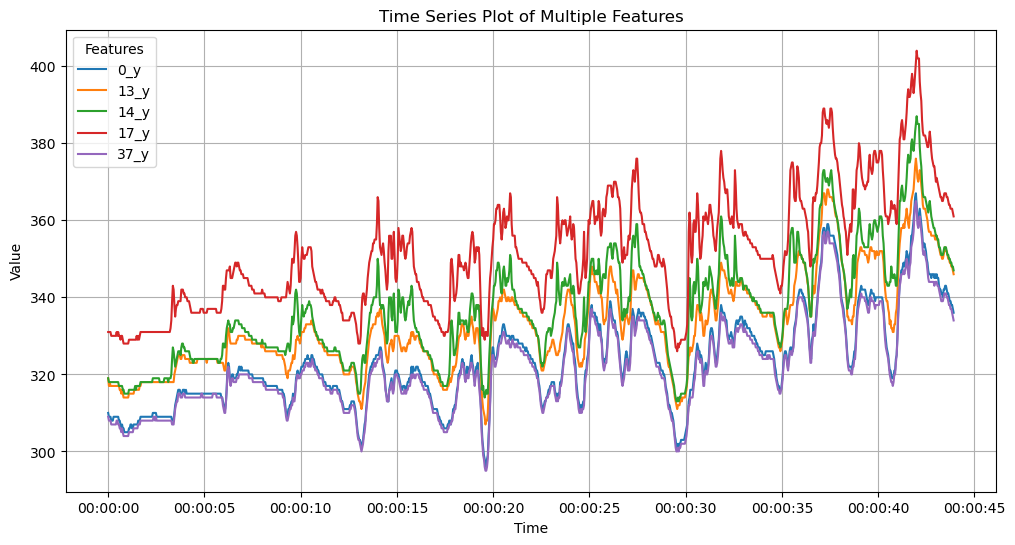

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Veri Setini Yükleme
file_path = "data/selected_lip_coordinates_y_only.csv"
df = pd.read_csv(file_path)

# 'time' sütununu tarih veya zaman olarak kullanmak
df['time'] = pd.to_datetime(df['time'], unit='s')  # Eğer zaman saniye cinsindense unit='s' ekleyebilirsiniz
df.set_index("time", inplace=True)

# 2. Zaman Serisi Doğrulama
print("Time column is increasing:", df.index.is_monotonic_increasing)
print("Missing values:")
print(df.isnull().sum())

# Zaman bilgisini x ekseni olarak belirle
time = df.index

# 3. Zaman Serisi Görselleştirme
plt.figure(figsize=(12, 6))

# Her sütunu ayrı ayrı çiz
for col in df.columns:
    plt.plot(time, df[col], label=col)

# Grafik ayarları
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Time Series Plot of Multiple Features")
plt.legend(title="Features")
plt.grid(True)
plt.show()
plt.close()

In [71]:
# 4. ADF Durağanlık Testi
def adf_test(series):
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    if result[1] <= 0.05:
        print("Seri durağandır.")
        return True
    else:
        print("Seri durağan değildir.")
        return False

print("Durağanlık Testi Sonuçları:")
non_stationary_columns = []
for column in df.columns:
    print(f"\n{column} için ADF Testi:")
    is_stationary = adf_test(df[column])
    if not is_stationary:
        non_stationary_columns.append(column)

Durağanlık Testi Sonuçları:

0_y için ADF Testi:
ADF Statistic: -3.7485014333320894
p-value: 0.003480414287093404
Critical Values:
   1%: -3.4363635475753824
   5%: -2.864195245967465
   10%: -2.5681837404258903
Seri durağandır.

13_y için ADF Testi:
ADF Statistic: -3.000433760974851
p-value: 0.03485391230900469
Critical Values:
   1%: -3.436391325753478
   5%: -2.864207498909067
   10%: -2.5681902663042324
Seri durağandır.

14_y için ADF Testi:
ADF Statistic: -3.151844102169366
p-value: 0.022946895286145602
Critical Values:
   1%: -3.436402509014354
   5%: -2.8642124318084456
   10%: -2.568192893555997
Seri durağandır.

17_y için ADF Testi:
ADF Statistic: -3.0837762846470715
p-value: 0.027777346392390708
Critical Values:
   1%: -3.436402509014354
   5%: -2.8642124318084456
   10%: -2.568192893555997
Seri durağandır.

37_y için ADF Testi:
ADF Statistic: -3.7284330287792766
p-value: 0.0037305356545876025
Critical Values:
   1%: -3.4363635475753824
   5%: -2.864195245967465
   10%: -2.56

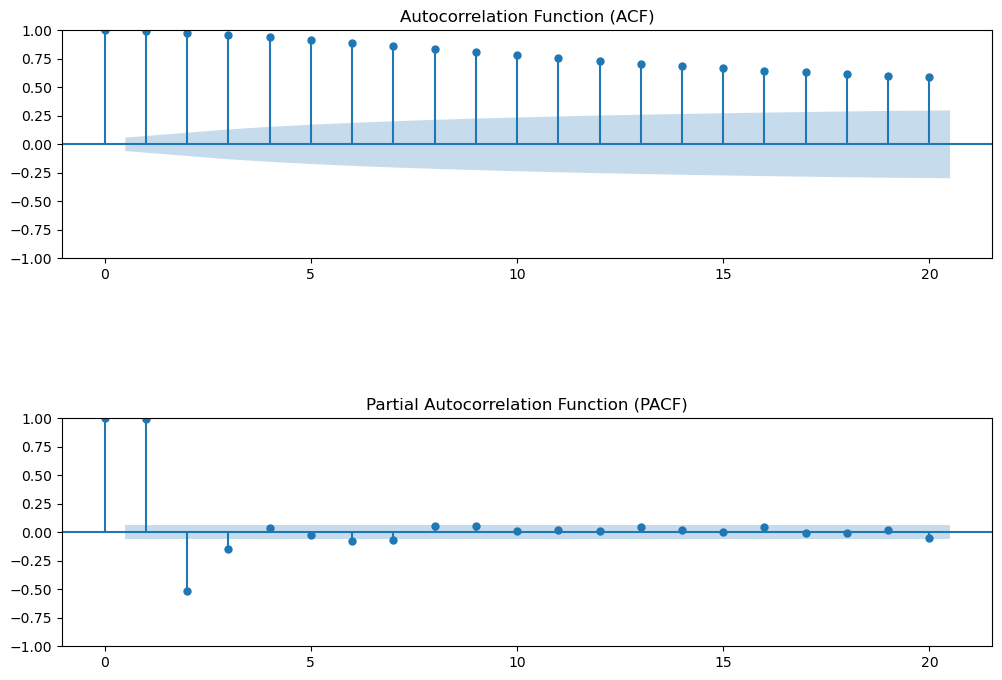

In [73]:
# 5. ACF ve PACF Grafikleri
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df.dropna().iloc[:, 0], ax=ax[0], lags=20)
ax[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(df.dropna().iloc[:, 0], ax=ax[1], lags=20)
ax[1].set_title("Partial Autocorrelation Function (PACF)")
plt.subplots_adjust(hspace=0.7, wspace=0.4)
plt.show()

In [75]:
# 'time' sütununu çıkararak sadece değişkenleri seç
data = df.astype("float64")

# Tahminleri saklamak için boş liste
rolling_forecast = []

# VAR modelini tüm veriyle eğit
var_model = VAR(data)
var_model_fit = var_model.fit(maxlags=1)

# Modelin gerektirdiği gecikme sayısını öğren
lags = var_model_fit.k_ar

# Geçmiş veriyi başlat (ilk 'lags' gözlemi kullanarak)
history = data.values[:lags]

# Tüm zaman adımları için kaydırmalı tahmin yap
for t in range(lags, len(data)):
    # Bir adım tahmin yap (Son 'lags' gözlemi kullanarak)
    yhat = var_model_fit.forecast(y=history[-lags:], steps=1)
    
    # Tahmini kaydet
    rolling_forecast.append(yhat[0])
    
    # Gerçek değeri ekleyerek veri setini güncelle
    history = np.vstack([history, data.iloc[t].values])

# Tahminleri DataFrame formatına çevir
rolling_forecast_df = pd.DataFrame(rolling_forecast, columns=data.columns)

# Gerçek ve tahmin edilen değerleri birleştirmek için DataFrame oluştur
comparison_df = data.iloc[lags:].reset_index(drop=True).copy()  # Gerçek değerler
rolling_forecast_df = rolling_forecast_df.reset_index(drop=True)  # Tahmin edilen değerler

# Gerçek ve tahmin edilen değerleri yanyana birleştir
for col in data.columns:
    comparison_df[f"{col}_pred"] = rolling_forecast_df[col]

# Hata metrikleri hesaplama
mae_values = {col: mean_absolute_error(comparison_df[col], comparison_df[f"{col}_pred"]) for col in data.columns}
mse_values = {col: mean_squared_error(comparison_df[col], comparison_df[f"{col}_pred"]) for col in data.columns}
rmse_values = {col: np.sqrt(mse_values[col]) for col in data.columns}
mape_values = {col: np.mean(np.abs((comparison_df[col] - comparison_df[f"{col}_pred"]) / comparison_df[col])) * 100 for col in data.columns}

# Hata metriklerini DataFrame'e çevir
error_metrics_df = pd.DataFrame({
    "Feature": data.columns,
    "MAE": mae_values.values(),
    "MSE": mse_values.values(),
    "RMSE": rmse_values.values(),
    "MAPE": mape_values.values()
})

# Sonuçları ekranda göster
print("Gerçek vs Tahmin Edilen Değerler:")
print(comparison_df)
print("------------------------------------------------------------------------------")
print("\nHata Metrikleri (MAE, MSE, RMSE, MAPE):")
print(error_metrics_df)

Gerçek vs Tahmin Edilen Değerler:
        0_y   13_y   14_y   17_y   37_y    0_y_pred   13_y_pred   14_y_pred  \
0     309.0  317.0  318.0  331.0  308.0  309.801541  318.721868  318.801297   
1     309.0  318.0  318.0  331.0  308.0  308.726589  317.089819  318.060475   
2     309.0  317.0  318.0  331.0  308.0  308.791473  317.855999  318.256224   
3     308.0  317.0  318.0  330.0  307.0  308.726589  317.089819  318.060475   
4     308.0  317.0  318.0  330.0  307.0  307.897623  316.829782  317.739186   
...     ...    ...    ...    ...    ...         ...         ...         ...   
1093  339.0  349.0  349.0  363.0  337.0  338.881122  348.546955  349.776736   
1094  338.0  348.0  349.0  363.0  337.0  338.399193  348.258484  348.724389   
1095  338.0  348.0  348.0  363.0  336.0  337.885617  347.559103  348.805478   
1096  337.0  347.0  348.0  362.0  335.0  337.389125  347.392615  348.179316   
1097  336.0  346.0  347.0  361.0  334.0  336.495276  346.366398  347.662278   

       17_y_pred 

C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 40ms will be used.
  self._init_dates(dates, freq)
